### Test power_iteration function

In [ ]:
import numpy as np  
from svd_engine import power_iteration

In [ ]:
M = np.array([[1, 2], [2, 4]])

In [ ]:
eigenvalue, eigenvector = power_iteration(M, num_iterations=100)
print(eigenvalue)
print(eigenvector)

In [ ]:
from svd_engine import deflation

In [ ]:
M_deflated = deflation(M,eigenvalue,eigenvector)

In [ ]:
print(M_deflated)

In [ ]:
from svd_engine import eigen_decompose
M = np.array([[1, 2], [2, 4]])

In [ ]:
print(eigen_decompose(M,2,100))

In [ ]:
import numpy as np  
from svd_engine import custom_svd,reconstruct_svd
M = np.array([[1, 2], [2, 4]])

In [ ]:
# Pass M and the rank k (e.g., k=2) to custom_svd
U, sigma, Vt = custom_svd(M, k=6)
M_rec = reconstruct_svd(U, sigma, Vt)

In [ ]:
# Calculate Frobenius norm of the difference matrix
loss = np.linalg.norm(M - M_rec)
# MSE
mean_loss = np.mean((M - M_rec) ** 2)
# Reconstruction loss
norm_loss = np.linalg.norm(M - M_rec) / np.linalg.norm(M)


In [ ]:
print(loss)
print(mean_loss)
print(norm_loss)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from svd_engine import custom_svd, reconstruct_svd

# 1. Create a 32x32 synthetic grayscale image (a simple 2D pattern)
x = np.linspace(-3, 3, 32)
y = np.linspace(-3, 3, 32)
X, Y = np.meshgrid(x, y)
# Create a radial wave pattern, scaled to [0, 1]
original_img = (np.sin(X**2 + Y**2) + 1) / 2.0 

# 2. Perform Custom SVD (We will keep the top 8 singular values)
k = 3
U, sigma, Vt = custom_svd(original_img, k=k)

# 3. Reconstruct the image
reconstructed_img = reconstruct_svd(U, sigma, Vt)

# 4. Display both images side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot Original
axes[0].imshow(original_img, cmap='gray')
axes[0].set_title("Original 32x32 Image")
axes[0].axis("off")

# Plot Reconstructed
axes[1].imshow(reconstructed_img, cmap='gray')
axes[1].set_title(f"Reconstructed (k={k})")
axes[1].axis("off")

plt.show()


In [ ]:
import numpy as np
from svd_engine import custom_svd   # returns U, sigma, Vt

# 32×32 test matrix (the one you used in the notebook cell)
x = np.linspace(-3, 3, 32)
y = np.linspace(-3, 3, 32)
X, Y = np.meshgrid(x, y)
M = (np.sin(X**2 + Y**2) + 1) / 2.0   # values in [0,1]

# Compute *full* SVD (k = 32) to get every singular value
_, full_sigma, _ = custom_svd(M, k=32)

# Print singular values and cumulative energy
total_energy = np.sum(full_sigma**2)
cumulative = np.cumsum(full_sigma**2) / total_energy * 100

print("Singular values (descending):")
print(full_sigma.round(4))
print("\nCumulative energy (% of total) after each singular value:")
for i, pct in enumerate(cumulative, start=1):
    print(f"  k={i:2d}: {pct:6.2f}%")


--- IMAGE PIPELINE TEST ---
1. Loading Image...
   Shape: (4318, 7680, 3), Type: float64, Min: 0.0, Max: 1.0
2. Splitting Channels...
3. Visualizing Channels...


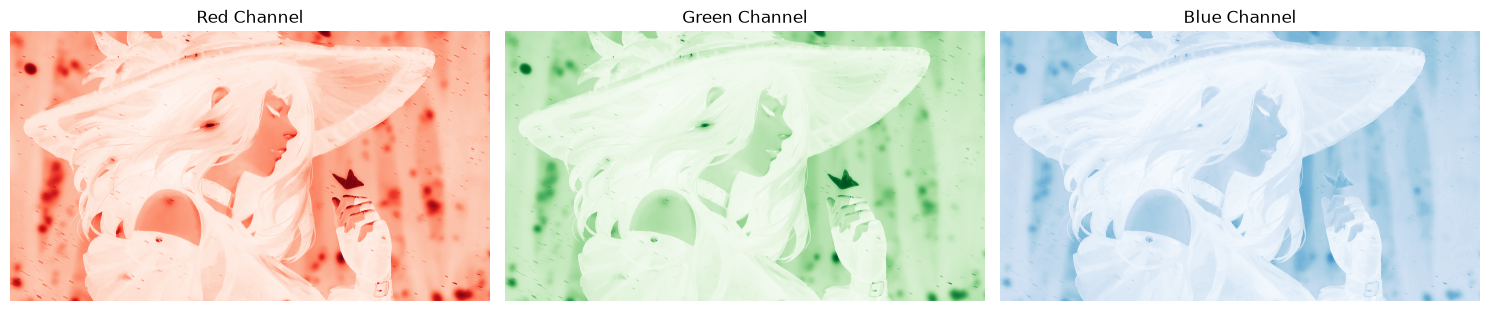

4. Chopping into 32x32 blocks...
   Generated 32400 blocks per channel.
5. Stitching blocks back into channels...
   Red channel perfect match: True
   Green channel perfect match: True
   Blue channel perfect match: True
6. Merging channels back to RGB...
   Reconstructed dtype: float64, shape: (4318, 7680, 3)
   Full image perfect match: True
7. Saving reconstructed image...
   Saved successfully to ../output/pipeline_test.jpg
8. Displaying comparison...


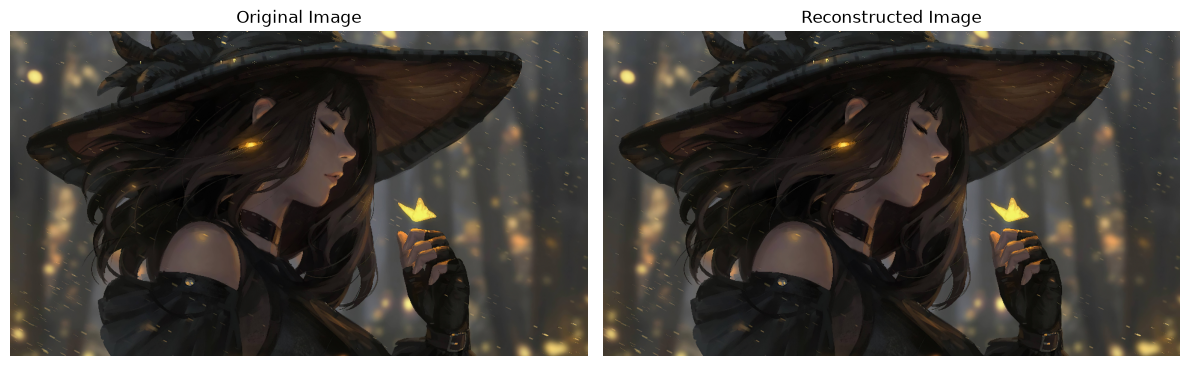


--- PIPELINE TEST COMPLETE ---


In [1]:
import os
import importlib
import numpy as np
import matplotlib.pyplot as plt
import image_pipeline
importlib.reload(image_pipeline)
from image_pipeline import (
    load_image, 
    split_channels, 
    image_to_blocks, 
    blocks_to_image, 
    merge_channels, 
    save_image
)

print('--- IMAGE PIPELINE TEST ---')
image_path = '../samples/image.jpg'
if not os.path.exists(image_path):
    print(f'Error: Image not found at {image_path}')
else:
    # 1. Load Image
    print('1. Loading Image...')
    image = load_image(image_path)
    print(f'   Shape: {image.shape}, Type: {image.dtype}, Min: {image.min()}, Max: {image.max()}')

    # 2. Split Channels
    print('2. Splitting Channels...')
    r, g, b = split_channels(image)

    # 3. Visualize Heatmaps
    print('3. Visualizing Channels...')
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(r, cmap='Reds'); axes[0].set_title('Red Channel'); axes[0].axis('off')
    axes[1].imshow(g, cmap='Greens'); axes[1].set_title('Green Channel'); axes[1].axis('off')
    axes[2].imshow(b, cmap='Blues'); axes[2].set_title('Blue Channel'); axes[2].axis('off')
    plt.tight_layout()
    plt.show()

    # 4. Split into blocks
    print('4. Chopping into 32x32 blocks...')
    block_size = 32
    r_blocks, r_padded_shape = image_to_blocks(r, block_size)
    g_blocks, g_padded_shape = image_to_blocks(g, block_size)
    b_blocks, b_padded_shape = image_to_blocks(b, block_size)
    print(f'   Generated {len(r_blocks)} blocks per channel.')

    # 5. Stitch blocks back together
    print('5. Stitching blocks back into channels...')
    original_shape = r.shape
    r_recon = blocks_to_image(r_blocks, r_padded_shape, original_shape, block_size)
    g_recon = blocks_to_image(g_blocks, g_padded_shape, original_shape, block_size)
    b_recon = blocks_to_image(b_blocks, b_padded_shape, original_shape, block_size)

    # Verify lossless block processing
    print(f'   Red channel perfect match: {np.array_equal(r, r_recon)}')
    print(f'   Green channel perfect match: {np.array_equal(g, g_recon)}')
    print(f'   Blue channel perfect match: {np.array_equal(b, b_recon)}')

    # 6. Merge Channels
    print('6. Merging channels back to RGB...')
    reconstructed_image = merge_channels(r_recon, g_recon, b_recon)
    print(f'   Reconstructed dtype: {reconstructed_image.dtype}, shape: {reconstructed_image.shape}')
    print(f'   Full image perfect match: {np.array_equal(image, reconstructed_image)}')

    # 7. Save Image
    print('7. Saving reconstructed image...')
    os.makedirs('../output', exist_ok=True)
    output_path = '../output/pipeline_test.jpg'
    save_image(reconstructed_image, output_path)
    print(f'   Saved successfully to {output_path}')

    # 8. Final Visualization
    # Downsample for display to avoid memory issues with very large images
    print('8. Displaying comparison...')
    step = max(1, image.shape[0] // 500)
    orig_small = image[::step, ::step, :].copy()
    recon_small = np.ascontiguousarray(reconstructed_image[::step, ::step, :], dtype=np.float64)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(orig_small)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(recon_small)
    axes[1].set_title('Reconstructed Image')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    print('\n--- PIPELINE TEST COMPLETE ---')
